### Name: Dibyanshu Ratna Bajracharya
### ID: 2408571

# Worksheet Week 4

# Introduction to Keras

In [4]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [5]:
import os
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

## Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification

### Task 1: Data Preparation

Loading the Data

• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• use train folder for training and test for testing.

• Extract the corresponding labels for each image.

Hints:

• Ensure that the images are resized to a consistent shape (e.g., 28x28).

• Convert labels to one-hot encoded format for multi-class classification

In [6]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/6th Sem/Artificial Intelligence and Machine Learning/Week 4/devnagari digit.zip"
extract_path = "/content/devnagari"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

for root, dirs, files in os.walk(extract_path):
    print(root)

base_path = extract_path

if len(os.listdir(base_path)) == 1:
    base_path = os.path.join(base_path, os.listdir(base_path)[0])

train_dir = os.path.join(base_path, "Train")
test_dir = os.path.join(base_path, "Test")

print("Train Path:", train_dir)
print("Test Path:", test_dir)

img_size = 28

def load_data(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            img = Image.open(img_path).convert("L")
            img = img.resize((img_size, img_size))
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

x_train, y_train = load_data(train_dir)
x_test, y_test = load_data(test_dir)

x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("✅ Training shape:", x_train.shape, y_train.shape)
print("✅ Testing shape:", x_test.shape, y_test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted!
/content/devnagari
/content/devnagari/DevanagariHandwrittenDigitDataset
/content/devnagari/DevanagariHandwrittenDigitDataset/Test
/content/devnagari/DevanagariHandwrittenDigitDataset/Test/digit_4
/content/devnagari/DevanagariHandwrittenDigitDataset/Test/digit_1
/content/devnagari/DevanagariHandwrittenDigitDataset/Test/digit_9
/content/devnagari/DevanagariHandwrittenDigitDataset/Test/digit_2
/content/devnagari/DevanagariHandwrittenDigitDataset/Test/digit_3
/content/devnagari/DevanagariHandwrittenDigitDataset/Test/digit_8
/content/devnagari/DevanagariHandwrittenDigitDataset/Test/digit_0
/content/devnagari/DevanagariHandwrittenDigitDataset/Test/digit_6
/content/devnagari/DevanagariHandwrittenDigitDataset/Test/digit_5
/content/devnagari/DevanagariHandwrittenDigitDataset/Test/digit_7
/content/devnagari/DevanagariHandwrittenDigitDataset/Train
/co

### Task 2: Build the FCN Model

Model Architecture

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:

– 1st hidden layer: 64 neurons

– 2nd hidden layer: 128 neurons

– 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='sigmoid', input_shape=(784,)),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

### Task 3: Compile the Model

Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy), and evaluation metric (e.g., accuracy)

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Task 4: Train the Model

Model Training

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of
epochs to 20.

• Use validation split (validation data. (split=0.2) to monitor the model’s performance on validation data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2684 - loss: 1.9748

107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4748 - loss: 1.5933 - val_accuracy: 0.0000e+00 - val_loss: 7.3355
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8429 - loss: 0.4870 - val_accuracy: 0.0000e+00 - val_loss: 8.6704
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9193 - loss: 0.2760 - val_accuracy: 0.0000e+00 - val_loss: 9.0886
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9463 - loss: 0.1892 - val_accuracy: 0.0000e+00 - val_loss: 9.5572


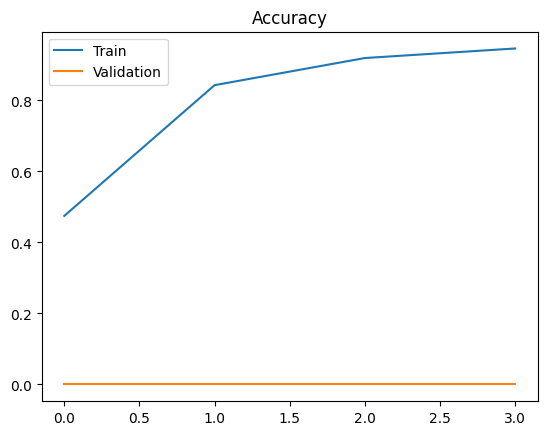

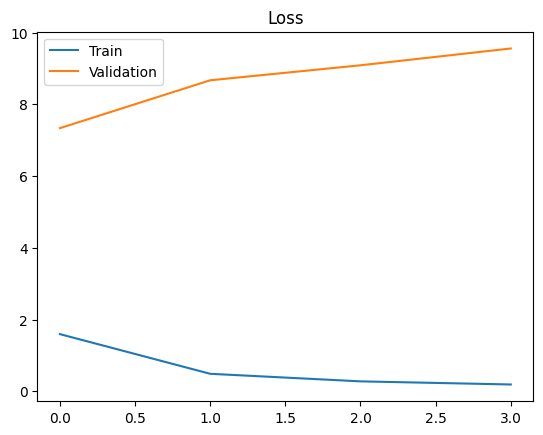

In [10]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

### Task 5: Evaluate the Model

Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.



In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7567 - loss: 2.0585
Test Accuracy: 0.7566666603088379


### Task 6: Save and Load the Model

Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.


In [12]:
# Save
model.save("devnagari_model.h5")

# Load
loaded_model = tf.keras.models.load_model("devnagari_model.h5")

# Re-evaluate
loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7567 - loss: 2.0585
Loaded Model Accuracy: 0.7566666603088379


### Task 7: Predictions

Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

In [13]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", true_labels[0])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted: 0
Actual: 0


The model successfully generated predictions using model.predict(). The predicted probabilities were converted into class labels using np.argmax(). The predicted labels were compared with true labels to evaluate performance. The model correctly predicted the class for the sample tested.